In [2]:
import pandas as pd
import numpy as np 
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import joblib # Para salvar os normalizadores
from tensorflow.keras import initializers
import os

In [3]:
def create_delta_data(local_data):
    OriginalData = pd.read_csv(local_data)
    OriginalData.index = (np.arange(0, len(OriginalData), 1).astype(float) * 0.07).round(5)
    OriginalData = OriginalData.drop(columns=["x(Wd,We)", "y(Wd,We)", "tempo"])
    theta = OriginalData["theta(Wd,We)"].to_numpy()
    theta_0 = theta[:-1]
    theta_1 = theta[1:]
    delta_theta = (theta_1 - theta_0) / 0.07
    wd_alinhado = OriginalData['Wd'].iloc[:-1]  
    we_alinhado = OriginalData['We'].iloc[:-1] 
    wd_true_alinhado = OriginalData['Wd_true'].iloc[:-1]
    we_true_alinhado = OriginalData['We_true'].iloc[:-1]
    df_new = pd.DataFrame({
        'Wd': wd_alinhado,
        'We': we_alinhado,
        'delta_theta': delta_theta,
        'Wd_true': wd_true_alinhado,
        'We_true': we_true_alinhado
    })
    print(df_new.head())
    print("Shape do novo_df:", df_new.shape)
    return df_new

In [4]:
def root_mean_squared_error(y_true, y_pred):
    y_true_np = y_true.numpy() if hasattr(y_true, 'numpy') else y_true
    y_pred_np = y_pred.numpy() if hasattr(y_pred, 'numpy') else y_pred
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def custom_train_model_with_es_physics(model,
                                       train_x, train_y,
                                       x_val, y_val,
                                       x_test, y_test,
                                       restrictions_data,
                                       Ts, L, R,
                                       y_scaler,
                                       lambda1=1.0, lambda2=1.0,
                                       epochs=5000, patience=50,
                                       min_delta=0, plot=True,
                                       learning_rate=0.001, use_early_stopping=True):
    """
    Treina um modelo Keras com Adam + Early Stopping e adiciona um termo
    físico MSE_f na loss:

        MSE_f = mean( ((y[k] - y[k-1]) / Ts - (R/L)*(Wd[k-1] - We[k-1]))^2 )

    Loss = lambda1 * MSE_d + lambda2 * MSE_f
    """

    # converter para tf.Tensor float32
    def to_tensor(x):
        return tf.constant(x, dtype=tf.float32) if not tf.is_tensor(x) else tf.cast(x, tf.float32)
    train_x = to_tensor(train_x); train_y = to_tensor(train_y)
    x_val   = to_tensor(x_val);   y_val   = to_tensor(y_val)
    x_test  = to_tensor(x_test);  y_test  = to_tensor(y_test)
    #restrictions_data = to_tensor(restrictions_data)

    optimizer = Adam(learning_rate=learning_rate)
    mse_loss  = MeanSquaredError()

    train_hist, val_hist = [], []
    best_val, wait, best_w = float('inf'), 0, None

    print(f"Treinando com Ts={Ts}, L={L}, R={R}, λ1={lambda1}, λ2={lambda2}")
    for epoch in range(1, epochs+1):
        with tf.GradientTape() as tape:
            # 1) predições
            y_pred = model(train_x, training=True)  # shape [N,1]

            # 2) termo convencional MSE_d
            MSE_d = mse_loss(train_y, y_pred)

            # 3) termo físico MSE_f
            # descartamos o primeiro ponto: predições[1:], predições[:-1]
            #y_k   = y_pred[1:]
            #y_km1 = y_pred[:-1]
            # entradas correspondentes Wd, We no instante k-1
            x1_km1 = restrictions_data[:, 0]   # Wd
            x2_km1 = restrictions_data[:, 1]   # We
            #x1_km1 = train_x[:, 0]  # Wd
            #x2_km1 = train_x[:, 1]  # We
            # calcula derivada aproximada
            #dy_dt = (y_k - y_km1) / Ts
            phys_real  = ((R / L) * (x1_km1 - x2_km1)) 

            phys_real = phys_real.reshape((-1, 1))  # shape [N-1, 1]
            phys_norm = y_scaler.transform(phys_real)
            MSE_f = tf.reduce_mean(tf.square(y_pred - phys_norm))

            # 4) loss total
            loss = lambda1 * MSE_d + lambda2 * MSE_f

        # grads e atualização
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # validação
        yv = model(x_val, training=False)
        val_d = mse_loss(y_val, yv)
        # para simplicidade não calculo val_f

        train_hist.append(loss.numpy())
        val_hist.append(val_d.numpy())

        if use_early_stopping:
        # early stopping
            if val_d.numpy() < best_val - min_delta:
                best_val = val_d.numpy(); wait = 0
                best_w = model.get_weights()
            else:
                wait += 1

            if wait >= patience:
                print(f"Early stopping na época {epoch}")
                model.set_weights(best_w)
                break

        if epoch % (epochs/5) == 0 or epoch == 1:
            print(f"Epoch {epoch}: Loss={loss.numpy():.4g}, MSE_d={MSE_d.numpy():.4g}, MSE_f={MSE_f.numpy():.4g}, Val MSE={val_d.numpy():.4g}")

    # avaliando métricas finais
    def eval_metrics(x, y):
        yp = model(x, training=False)
        y_np, yp_np = y.numpy(), yp.numpy()
        return {
            'R2': r2_score(y_np, yp_np),
            'MSE': mean_squared_error(y_np, yp_np),
            'RMSE': root_mean_squared_error(y_np, yp_np),
            'MAPE': mean_absolute_percentage_error(y_np, yp_np)
        }

    metrics = {
        'Training':   eval_metrics(train_x, train_y),
        'Validation': eval_metrics(x_val,   y_val),
        'Test':       eval_metrics(x_test,  y_test),
    }
    if plot:
        for split, m in metrics.items():
            print(f"\n{split} Metrics:")
            for k, v in m.items():
                print(f"  {k}: {v:.4g}")
            
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # CORREÇÃO: Conversão robusta para arrays numpy para cálculo de métricas sklearn
    # Usamos hasattr(var, 'numpy') para verificar se é um Tensor antes de chamar .numpy()
    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred
    # opcional: plot de loss
    if plot:
        plt.plot(train_hist, label='Train Loss')
        plt.plot(val_hist,   label='Val MSE_d')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True)
        plt.show()

        # Gráficos comparativos
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))
        datasets = [
            ('Treinamento', train_y_np, train_pred_np), 
            ('Validação', y_val_np, val_pred_np),
            ('Teste', y_test_np, test_pred_np)
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            y_true_flat = np.ravel(y_true)
            y_pred_flat = np.ravel(y_pred)
            axs[i].plot(y_true_flat, marker='o', label='Amostras Reais')
            axs[i].plot(y_pred_flat, marker='x', label='Valores Preditos')
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Índice')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        #print(model.trainable_variables)

    return metrics

In [5]:
def create_sequences(input_data, target_data, timesteps):

    X_seq, Y_seq = [], []
    
    # Itera sobre os dados, começando após o número de timesteps
    for i in range(timesteps, len(input_data)):
        # A sequência de entrada (X_seq) é a janela de dados de i-timesteps até i
        X_seq.append(input_data[i-timesteps:i])
        
        # O alvo (Y_seq) é o valor de saída no passo de tempo atual 'i'
        Y_seq.append(target_data[i])
    
    return np.array(X_seq), np.array(Y_seq)

In [6]:
def Recontruir_Theta(model, inputs_norm, local_data_original, y_scaler):
    """
    Reconstrói o sinal de Theta a partir da previsão de sua derivada,
    e calcula o MSE de forma correta e alinhada.
    Também plota dois gráficos: reconstrução de Theta e predição da rede.
    """
    df = create_delta_data(local_data_original)
    y_real = df[["delta_theta"]].to_numpy()
    # Predição da rede (na escala normalizada e real)
    Y_norm_pred = model.predict(inputs_norm)
    Y_pred_real = y_scaler.inverse_transform(Y_norm_pred).flatten()  # Derivada prevista (real)

    # Dados reais
    DataOrigi = pd.read_csv(local_data_original)
    Theta_true = DataOrigi["theta(Wd,We)"].to_numpy()

    # Reconstrução de Theta por integração de Euler
    theta_reconstruido = np.zeros_like(Y_pred_real)
    theta_reconstruido[0] = Theta_true[0] + Y_pred_real[0] * 0.07
    for i in range(1, len(Y_pred_real)):
        theta_reconstruido[i] = theta_reconstruido[i-1] + Y_pred_real[i] * 0.07
    
    # Ajustando os comprimentos
    offset = len(Theta_true) - len(theta_reconstruido)
    Theta_true_alinhado = Theta_true[:-offset]

    # Cálculo do erro
    mse = np.mean(np.square(Theta_true_alinhado - theta_reconstruido))
    print(f"MSE entre Theta Original e Reconstruído: {mse:.4g}")

    # ---------- PLOTS ----------
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Theta reconstruído
    axs[0].plot(Theta_true_alinhado, label='Theta Original (Alinhado)', color='orange', linestyle='--')
    axs[0].plot(theta_reconstruido, label='Theta Reconstruído', color='blue', alpha=0.8)
    axs[0].set_xlabel('Índice da Amostra (Alinhado)')
    axs[0].set_ylabel('Theta (rad)')
    axs[0].set_title('Theta Reconstruído vs Original')
    axs[0].legend()
    axs[0].grid(True)

    # Gráfico 2: Derivada prevista pela rede vs real (quando disponível)
    
    axs[1].plot(y_real[:-offset], label='Derivada Real', color='green', linestyle='--')
  
    axs[1].plot(Y_pred_real, label='Predição (Rede)', color='red', alpha=0.8)
    axs[1].set_xlabel('Índice da Amostra')
    axs[1].set_ylabel('Theta\' (rad/s)')
    axs[1].set_title('Predição da Derivada vs Real')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()
    # ---------------------------

    return mse

def Aval_Thetha(model, time_steps, y_scaler):
    train_x_seq, train_y_seq = create_sequences(train_x_norm, train_y_norm, time_steps)
    x_val_seq, y_val_seq = create_sequences(x_val_norm, y_val_norm, time_steps)
    x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, time_steps)
    mse_train = Recontruir_Theta(model, train_x_seq, "./Dados/DataSmoothSpline1.csv", y_scaler)
    mse_val = Recontruir_Theta(model, x_val_seq, "./Dados/DataSmoothSpline2.csv", y_scaler)
    mse_test = Recontruir_Theta(model, x_test_seq, "./Dados/DataSmoothSpline3.csv", y_scaler)
    return [mse_train, mse_val, mse_test]

In [7]:
def CreateModel(input_size = 2, output_size = 1, units = 10, time_steps = 2, 
                n_seed = [32, 67, 90, 546, 801], lam_1 = 1.0, lam_2 = 0.0, lr = 0.01, l2 = 0.8):
    """
    Cria um modelo Sequential com uma camada RNN e uma camada Dense.

    """
    train_x_seq, train_y_seq = create_sequences(train_x_norm, train_y_norm, time_steps)
    x_val_seq, y_val_seq = create_sequences(x_val_norm, y_val_norm, time_steps)
    x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, time_steps)
    
    model = keras.models.Sequential([
        keras.layers.SimpleRNN(units, return_sequences=False, input_shape=[time_steps, input_size],
                               kernel_initializer=initializers.GlorotUniform(seed=int(n_seed[0])),
                               recurrent_initializer=initializers.Orthogonal(seed=int(n_seed[1])),
                               bias_initializer=initializers.RandomNormal(seed=int(n_seed[2])),
                               kernel_regularizer= keras.regularizers.l2(l2)),
        #keras.layers.Dense(output_size, activation='linear',use_bias=False,kernel_initializer=initializers.GlorotUniform(seed=int(n_seed[3])))
        keras.layers.Dense(output_size,
        kernel_initializer=initializers.GlorotUniform(seed=int(n_seed[3])),
        bias_initializer=initializers.RandomNormal(seed=int(n_seed[4])))
    ])

    metrics = custom_train_model_with_es_physics(model,
                                       train_x = train_x_seq, train_y = train_y_seq,
                                       x_val = x_val_seq, y_val = y_val_seq,
                                       x_test = x_test_seq, y_test = y_test_seq,
                                       restrictions_data = Restrictions_data[:-time_steps,:],
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       y_scaler= y_scaler,
                                       lambda1= lam_1, lambda2=lam_2,
                                       epochs = 10000, patience=300,
                                       min_delta=0, plot=False,
                                       learning_rate= lr, use_early_stopping=True)

    
    return model, metrics

In [8]:
def Generate_Random_Models(units=10, time_steps=2, lam_1=0.5, lam_2=0.5, lr = 0.001, aval= True, l2 = 0.8):
    """
    Treina vários modelos com seeds e learning rates aleatórios,
    retornando o melhor modelo encontrado com base no MSE de teste.
    """
    best_test_mse = float('inf')
    best_test_r2 = None
    best_model = None
    best_metrics = None

    for i in range(10):
        # Seed aleatória
        np_seed = np.random.randint(1, 10000, size = 5)


        print(f"Modelo {i+1}: unidades = {units}, seed = {np_seed}, lr = {lr:.5f}")

        # Criação e treino do modelo
        model, metrics = CreateModel(
            units=units,
            time_steps=time_steps,
            lam_1=lam_1,
            lam_2=lam_2,
            n_seed=np_seed,
            lr=lr,
            l2 = l2
        )

        # Métricas do teste
        test_mse = metrics['Test']['MSE']
        if test_mse < best_test_mse:
            best_test_mse = test_mse
            best_model = model
            best_test_r2 = metrics['Test']['R2']
            best_metrics = metrics
            print(f"Novo melhor modelo: MSE = {best_test_mse:.4g}, R2 = {best_test_r2:.4g}, lr = {lr:.5f}")

    print(f"\nMelhor modelo final: MSE = {best_test_mse:.4g}, R2 = {best_test_r2:.4g}, unidades = {units},  lr = {lr:.5f}")
    if aval:
        Aval_Thetha(best_model, time_steps, y_scaler)

    return best_model, best_metrics


In [9]:
TrainData = create_delta_data("./Dados/DataSmoothSpline1.csv")
TestData = create_delta_data("./Dados/DataSmoothSpline3.csv")
ValData = create_delta_data("./Dados/DataSmoothSpline2.csv")

# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "delta_theta"
RESTRICTIONS = ["Wd_true", "We_true"]


Restrictions_data = TrainData[RESTRICTIONS].to_numpy()

print("\nShape de Restrictions_data:", Restrictions_data.shape)
print("Primeiras linhas de Restrictions_data:\n", Restrictions_data[:5])

# Convertendo para arrays numpy
train_x = TrainData[PREDICTORS].to_numpy()
train_y = TrainData[[TARGET]].to_numpy()
print(train_x.shape)

x_val = ValData[PREDICTORS].to_numpy()
y_val = ValData[[TARGET]].to_numpy()

x_test = TestData[PREDICTORS].to_numpy()
y_test = TestData[[TARGET]].to_numpy()


x_scaler = MinMaxScaler(feature_range=(-1, 1))
y_scaler = MinMaxScaler(feature_range=(-1, 1))

print("\nAjustando os normalizadores (scalers) com os dados de treino...")
x_scaler.fit(train_x)
y_scaler.fit(train_y)

joblib.dump(x_scaler, 'x_scaler.gz')
joblib.dump(y_scaler, 'y_scaler.gz')
print("Normalizadores salvos como 'x_scaler.gz' e 'y_scaler.gz'")

# AGORA, TRANSFORME TODOS OS CONJUNTOS DE DADOS com os scalers já ajustados
train_x_norm = x_scaler.transform(train_x)
train_y_norm = y_scaler.transform(train_y)

x_val_norm = x_scaler.transform(x_val)
y_val_norm = y_scaler.transform(y_val)

x_test_norm = x_scaler.transform(x_test)
y_test_norm = y_scaler.transform(y_test)

restric_norm = x_scaler.transform(Restrictions_data)
print("\nShape de Restrictions_data normalizado:", restric_norm.shape)

print("\nShape de X_train depois da normalização:", train_x_norm.shape)
print("Primeiras linhas de X_train normalizado:\n", train_x_norm[:5])
print("\nPrimeiras linhas de y_train normalizado:\n", train_y_norm[:5])


            Wd        We  delta_theta   Wd_true   We_true
0.00  2.046979  2.067159     0.004965  0.163271  0.093873
0.07  2.058519  2.079836     0.004959  0.242458  0.175944
0.14  2.069982  2.092437     0.004942  0.321637  0.258010
0.21  2.081302  2.104891     0.004909  0.400792  0.340061
0.28  2.092419  2.117138     0.004853  0.479896  0.422075
Shape do novo_df: (2145, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  2.250967  2.289211     0.008868  0.204149  0.077678
0.07  2.246293  2.286558     0.008856  0.283600  0.162385
0.14  2.241624  2.283906     0.008824  0.363042  0.247087
0.21  2.236964  2.281260     0.008762  0.442455  0.331776
0.28  2.232324  2.278624     0.008659  0.521806  0.416432
Shape do novo_df: (2026, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  1.866241  1.950911     0.007093  0.118729 -0.110797
0.07  1.870389  1.957288     0.007070  0.187222 -0.030969
0.14  1.874468  1.963593     0.007006  0.255708  0.048863
0.21  1.878425  

In [ ]:
# Cria uma pasta para salvar os modelos, se não existir
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# Inicializa uma lista para armazenar os resultados
results_list = []

# Laço principal de treinamento
for neurons in range(5, 16):
    print(f"\nIniciando testes com {neurons} neurônios...")
    for time_steps in range(2, 5):
        for l2 in [0.2, 0.7]:
            print(f"  Treinando: Neurônios={neurons}, Timesteps={time_steps}, L2={l2}")
            
            # Treina o modelo para a configuração atual
            best_model, best_metrics = Generate_Random_Models(
                units=neurons, 
                time_steps=time_steps, 
                l2=l2,
                lam_1=0.5,
                lam_2=0.5,
                lr=0.01,
                aval=False
            )
            
            # Define um nome de arquivo único e salva o modelo
            model_filename = f"saved_models/model_U{neurons}_TS{time_steps}_L2-{l2}.keras"
            best_model.save(model_filename)

            # Cria um registro com os resultados
            result_entry = {
                'neurons': neurons,
                'time_steps': time_steps,
                'l2_factor': l2,
                'model_file': model_filename,
                'R2_Train': best_metrics['Training']['R2'],
                'MSE_Train': best_metrics['Training']['MSE'],
                'R2_Validation': best_metrics['Validation']['R2'],
                'MSE_Validation': best_metrics['Validation']['MSE'],
                'R2_Test': best_metrics['Test']['R2'],
                'MSE_Test': best_metrics['Test']['MSE']
            }
            
            # Adiciona o registro à lista
            results_list.append(result_entry)

print("\nTreinamento concluído.")

# Converte a lista de resultados em um DataFrame do pandas
results_df = pd.DataFrame(results_list)

# Ordena o DataFrame pelo R2 de Teste (melhores primeiro)
results_df = results_df.sort_values(by='R2_Test', ascending=False)

# Salva o DataFrame em um arquivo CSV
results_df.to_csv('model_training_results.csv', index=False)

print("Planilha 'model_training_results.csv' salva com sucesso!")
print("\n--- 5 Melhores Modelos Encontrados ---")
print(results_df.head(5))


--- Carregando o melhor modelo ---
Melhor modelo a ser carregado: saved_models/model_U13_N28_TS3_L2-0.9.keras
Métricas de Teste do melhor modelo (R2): 0.8372
Métricas de Teste do melhor modelo (MSE): 0.008848

Modelo carregado com sucesso!


Model: "sequential_210"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_424 (SimpleRNN)      │ (None, 3, 13)          │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_425 (SimpleRNN)      │ (None, 8)              │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_210 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393 (1.54 KB)

 Trainable params: 393 (1.54 KB)

 Non-trainable params: 0 (0.00 B)


--- Avaliando o melhor modelo ---
            Wd        We  delta_theta   Wd_true   We_true
0.00  2.046979  2.067159     0.004965  0.163271  0.093873
0.07  2.058519  2.079836     0.004959  0.242458  0.175944
0.14  2.069982  2.092437     0.004942  0.321637  0.258010
0.21  2.081302  2.104891     0.004909  0.400792  0.340061
0.28  2.092419  2.117138     0.004853  0.479896  0.422075
Shape do novo_df: (2145, 5)
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
MSE entre Theta Original e Reconstruído: 0.02262


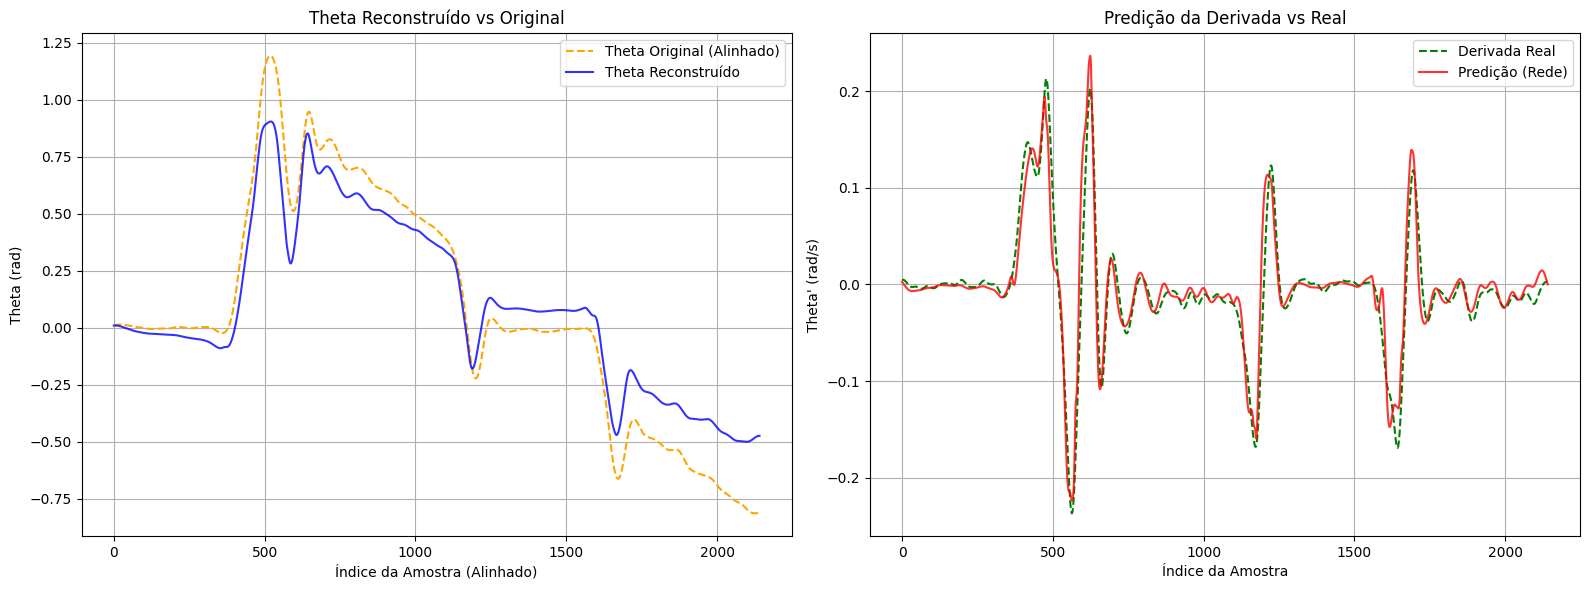

            Wd        We  delta_theta   Wd_true   We_true
0.00  1.866241  1.950911     0.007093  0.118729 -0.110797
0.07  1.870389  1.957288     0.007070  0.187222 -0.030969
0.14  1.874468  1.963593     0.007006  0.255708  0.048863
0.21  1.878425  1.969766     0.006880  0.324177  0.128705
0.28  1.882225  1.975761     0.006673  0.392606  0.208559
Shape do novo_df: (1325, 5)
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE entre Theta Original e Reconstruído: 0.04677


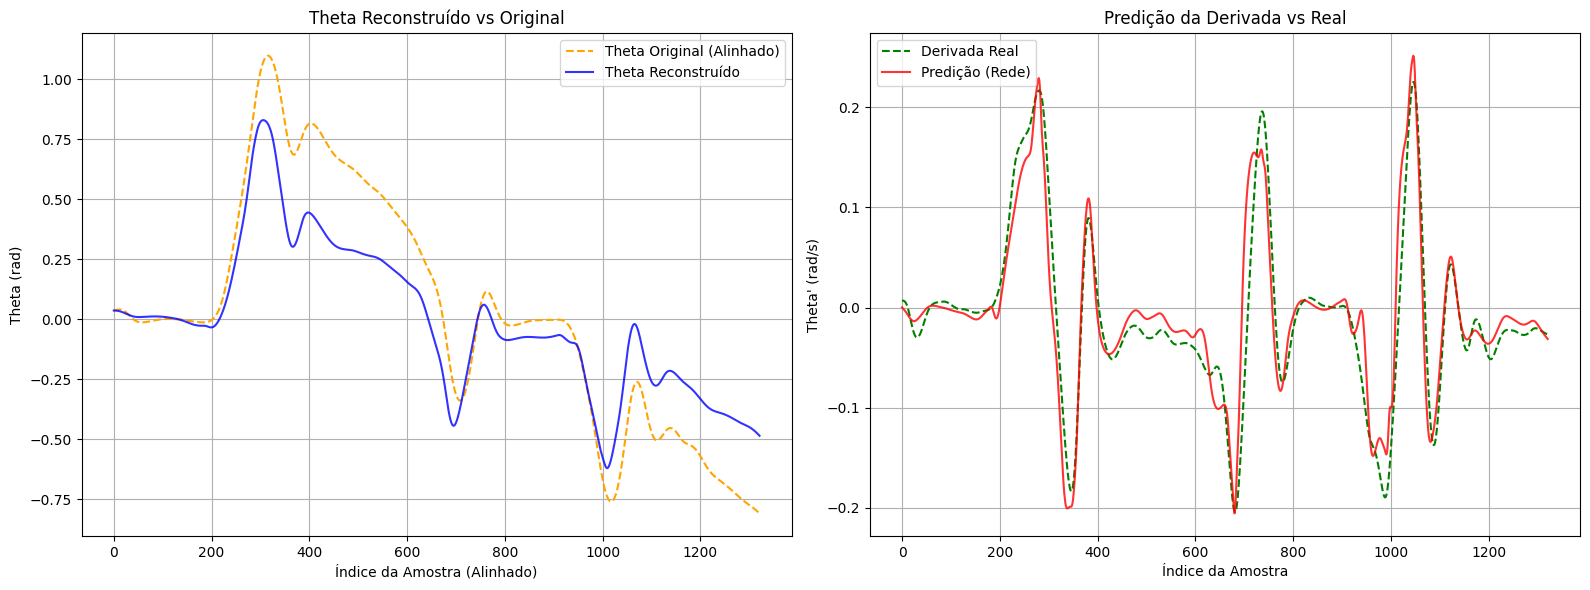

            Wd        We  delta_theta   Wd_true   We_true
0.00  2.250967  2.289211     0.008868  0.204149  0.077678
0.07  2.246293  2.286558     0.008856  0.283600  0.162385
0.14  2.241624  2.283906     0.008824  0.363042  0.247087
0.21  2.236964  2.281260     0.008762  0.442455  0.331776
0.28  2.232324  2.278624     0.008659  0.521806  0.416432
Shape do novo_df: (2026, 5)
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE entre Theta Original e Reconstruído: 0.04802


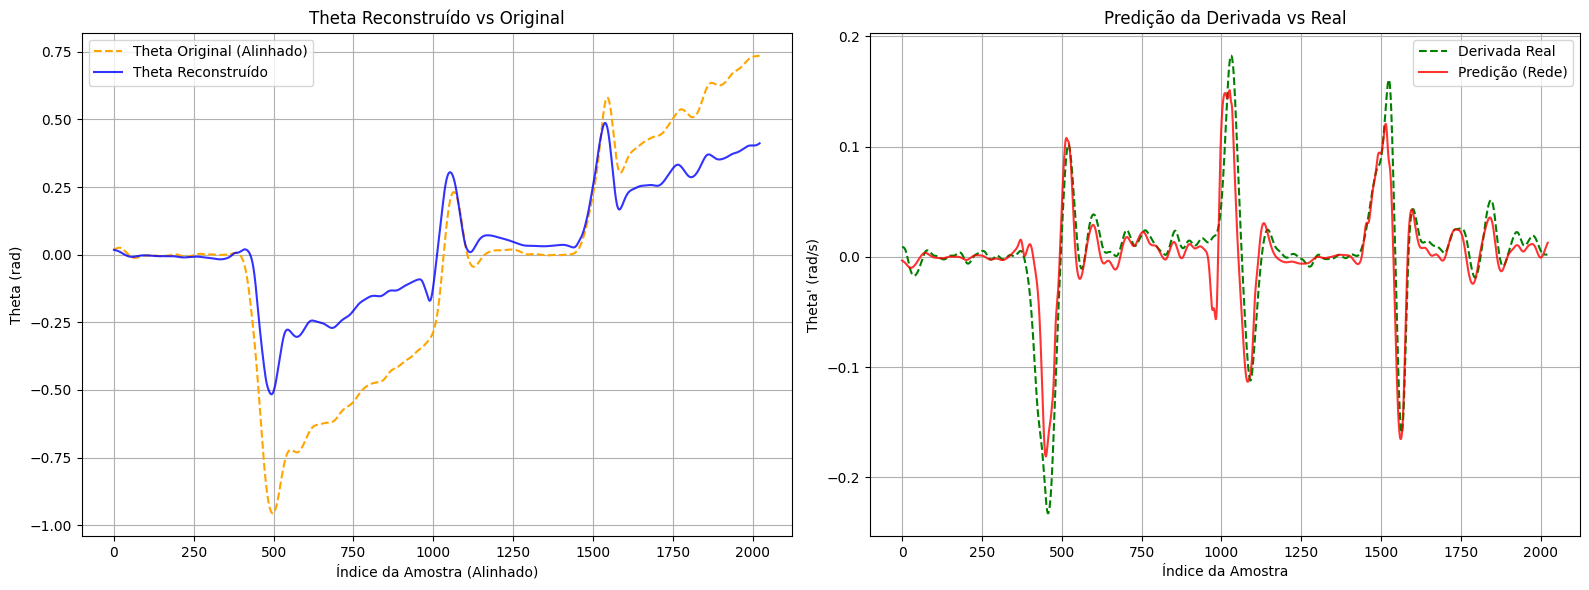

In [10]:

try:
    results_df = pd.read_csv('model_training_results.csv')
except FileNotFoundError:
    print("Erro: O arquivo 'model_training_results.csv' não foi encontrado. Certifique-se de que o treinamento foi executado.")
else:
    # 2. Encontre o melhor modelo
    # Como o DataFrame já está ordenado, o primeiro registro é o melhor
    best_model_row = results_df.iloc[0]
    best_model_path = best_model_row['model_file']

    print("\n--- Carregando o melhor modelo ---")
    print(f"Melhor modelo a ser carregado: {best_model_path}")
    print(f"Métricas de Teste do melhor modelo (R2): {best_model_row['R2_Test']:.4g}")
    print(f"Métricas de Teste do melhor modelo (MSE): {best_model_row['MSE_Test']:.4g}")
    
    # 3. Carregue o modelo
    try:
        # A função load_model carrega o modelo salvo
        best_model = keras.models.load_model(best_model_path)
        print("\nModelo carregado com sucesso!")
        
        # Opcional: verifique a estrutura do modelo
        best_model.summary()
        
    except FileNotFoundError:
        print(f"Erro: O arquivo do modelo '{best_model_path}' não foi encontrado.")

# Avaliação do melhor modelo
if 'best_model' in locals():
    print("\n--- Avaliando o melhor modelo ---")
    Aval_Thetha(best_model, time_steps=int(best_model_row['time_steps']), y_scaler=y_scaler)   
    #

            Wd        We  delta_theta   Wd_true   We_true
0.00  2.250967  2.289211     0.008868  0.204149  0.077678
0.07  2.246293  2.286558     0.008856  0.283600  0.162385
0.14  2.241624  2.283906     0.008824  0.363042  0.247087
0.21  2.236964  2.281260     0.008762  0.442455  0.331776
0.28  2.232324  2.278624     0.008659  0.521806  0.416432
Shape do novo_df: (2026, 5)
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MSE entre Theta Original e Reconstruído: 0.04802


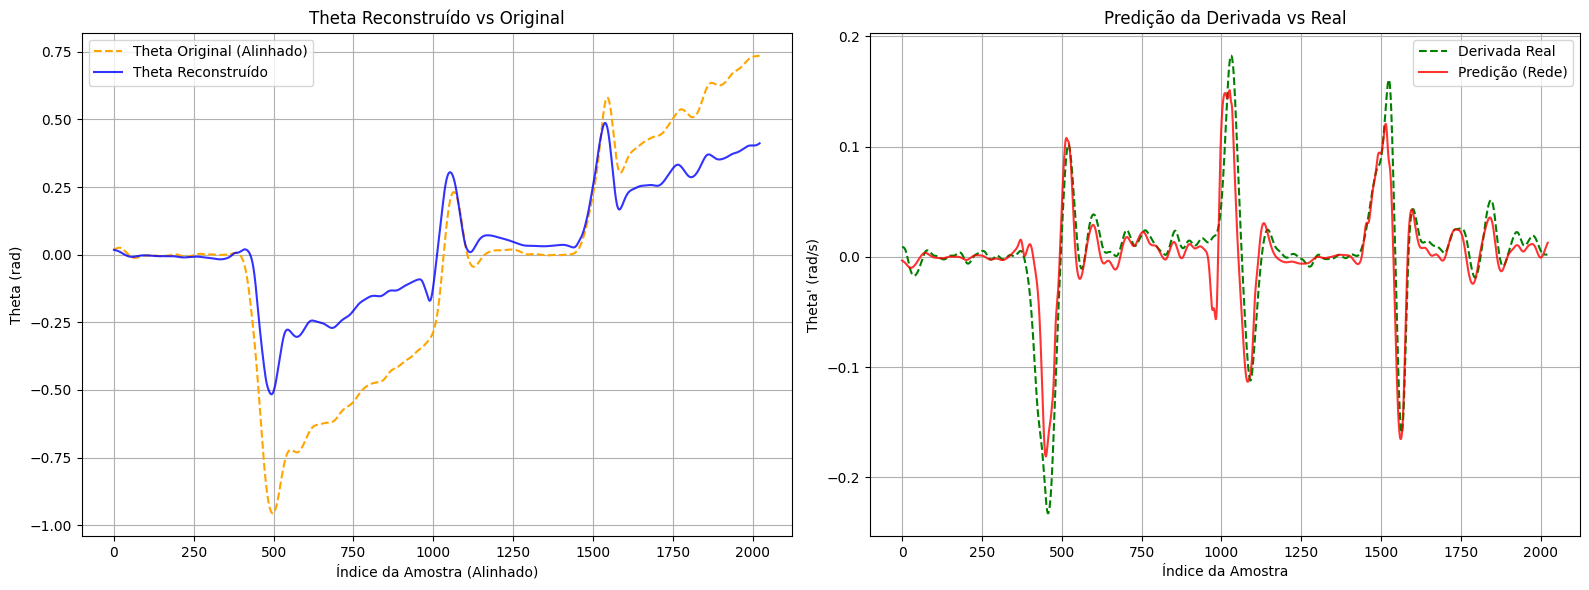

0.048018212105532705

In [13]:
def Salvar_Theta(model, inputs_norm, local_data_original, y_scaler):
    """
    Reconstrói o sinal de Theta a partir da previsão de sua derivada,
    e calcula o MSE de forma correta e alinhada.
    Também plota dois gráficos: reconstrução de Theta e predição da rede.
    """
    df = create_delta_data(local_data_original)
    y_real = df[["delta_theta"]].to_numpy()
    # Predição da rede (na escala normalizada e real)
    Y_norm_pred = model.predict(inputs_norm)
    Y_pred_real = y_scaler.inverse_transform(Y_norm_pred).flatten()  # Derivada prevista (real)

    # Dados reais
    DataOrigi = pd.read_csv(local_data_original)
    Theta_true = DataOrigi["theta(Wd,We)"].to_numpy()

    # Reconstrução de Theta por integração de Euler
    theta_reconstruido = np.zeros_like(Y_pred_real)
    theta_reconstruido[0] = Theta_true[0] + Y_pred_real[0] * 0.07
    for i in range(1, len(Y_pred_real)):
        theta_reconstruido[i] = theta_reconstruido[i-1] + Y_pred_real[i] * 0.07
    
    # Ajustando os comprimentos
    offset = len(Theta_true) - len(theta_reconstruido)
    Theta_true_alinhado = Theta_true[:-offset]

    # Cálculo do erro
    mse = np.mean(np.square(Theta_true_alinhado - theta_reconstruido))
    print(f"MSE entre Theta Original e Reconstruído: {mse:.4g}")

    # ---------- PLOTS ----------
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Theta reconstruído
    axs[0].plot(Theta_true_alinhado, label='Theta Original (Alinhado)', color='orange', linestyle='--')
    axs[0].plot(theta_reconstruido, label='Theta Reconstruído', color='blue', alpha=0.8)
    axs[0].set_xlabel('Índice da Amostra (Alinhado)')
    axs[0].set_ylabel('Theta (rad)')
    axs[0].set_title('Theta Reconstruído vs Original')
    axs[0].legend()
    axs[0].grid(True)

    # Gráfico 2: Derivada prevista pela rede vs real (quando disponível)
    
    axs[1].plot(y_real[:-offset], label='Derivada Real', color='green', linestyle='--')
  
    axs[1].plot(Y_pred_real, label='Predição (Rede)', color='red', alpha=0.8)
    axs[1].set_xlabel('Índice da Amostra')
    axs[1].set_ylabel('Theta\' (rad/s)')
    axs[1].set_title('Predição da Derivada vs Real')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    theta_file = pd.DataFrame(theta_reconstruido)
    theta_file.to_csv("theta_teste.csv")

    # ---------------------------

    return mse

x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, 3)
Salvar_Theta(best_model, x_test_seq, "./Dados/DataSmoothSpline3.csv", y_scaler)

In [11]:
#best_model.save("theta_model.h5")

from scipy.io import savemat

# Suponha que 'best_model' é o seu modelo Keras treinado
# best_model = keras.models.load_model('caminho/para/seu/modelo.keras')

# Crie um dicionário para armazenar os pesos
pesos_para_matlab = {}

# Itere sobre cada camada do seu modelo
for i, layer in enumerate(best_model.layers):
    pesos = layer.get_weights()
    if pesos: # Verifica se a camada tem pesos (ex: a camada Input não tem)
        # O get_weights() retorna uma lista [kernel, bias] para camadas Dense
        # e [kernel, recurrent_kernel, bias] para camadas RNN
        
        if 'rnn' in layer.name:
            pesos_para_matlab[f'camada_{i}_kernel'] = pesos[0]
            pesos_para_matlab[f'camada_{i}_recurrent_kernel'] = pesos[1]
            pesos_para_matlab[f'camada_{i}_bias'] = pesos[2]
        elif 'dense' in layer.name:
            pesos_para_matlab[f'camada_{i}_kernel'] = pesos[0]
            pesos_para_matlab[f'camada_{i}_bias'] = pesos[1]

# Salve o dicionário em um arquivo .mat
savemat('pesos_do_modelo.mat', pesos_para_matlab)

print("Arquivo 'pesos_do_modelo.mat' salvo com sucesso!")

Arquivo 'pesos_do_modelo.mat' salvo com sucesso!


In [68]:
def ajustar_saida_minimos_quadrados(model, X_train, Y_train, rnn_layer_index=-2):
   
    if not model.built:
        time_steps = X_train.shape[1]
        input_size = X_train.shape[2]
        model.build(input_shape=(None, time_steps, input_size))
        print(f"Modelo construído com input_shape={(None, time_steps, input_size)}")

    # 1) Extrair ativações da camada RNN selecionada
    feature_extractor = keras.Model(
        inputs=model.inputs,
        outputs=model.layers[rnn_layer_index].output
    )
    H = feature_extractor.predict(X_train, verbose=0)

    # 2) Preparar saída desejada (já normalizada)
    Y = Y_train

    # 3) Resolver mínimos quadrados com bias separado
    H_aug = np.hstack([H, np.ones((H.shape[0], 1))])  # adiciona coluna de 1 para bias
    W_ls, _, _, _ = np.linalg.lstsq(H_aug, Y, rcond=None)

    # 4) Separar pesos e bias
    W = W_ls[:-1, :]  # pesos
    b = W_ls[-1, :]   # bias

    # 5) Atualizar camada densa final
    dense_layer = model.layers[-1]
    dense_layer.set_weights([W, b])

    print(f"Ajuste de saída concluído! Pesos e bias atualizados na camada final.")
    return model

Model: "sequential_210"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_424 (SimpleRNN)      │ (None, 3, 13)          │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_425 (SimpleRNN)      │ (None, 8)              │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_210 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393 (1.54 KB)

 Trainable params: 393 (1.54 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_424 (SimpleRNN)      │ (None, 3, 13)          │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_425 (SimpleRNN)      │ (None, 8)              │           176 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 384 (1.50 KB)

 Trainable params: 384 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
(2023, 8)
(2145, 1)
(2142, 1)
            Wd        We  delta_theta   Wd_true   We_true
0.00  2.046979  2.067159     0.004965  0.163271  0.093873
0.07  2.058519  2.079836     0.004959  0.242458  0.175944
0.14  2.069982  2.092437     0.004942  0.321637  0.258010
0.21  2.081302  2.104891     0.004909  0.400792  0.340061
0.28  2.092419  2.117138     0.004853  0.479896  0.422075
Shape do novo_df: (2145, 5)
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MSE entre Theta Original e Reconstruído: 0.03131


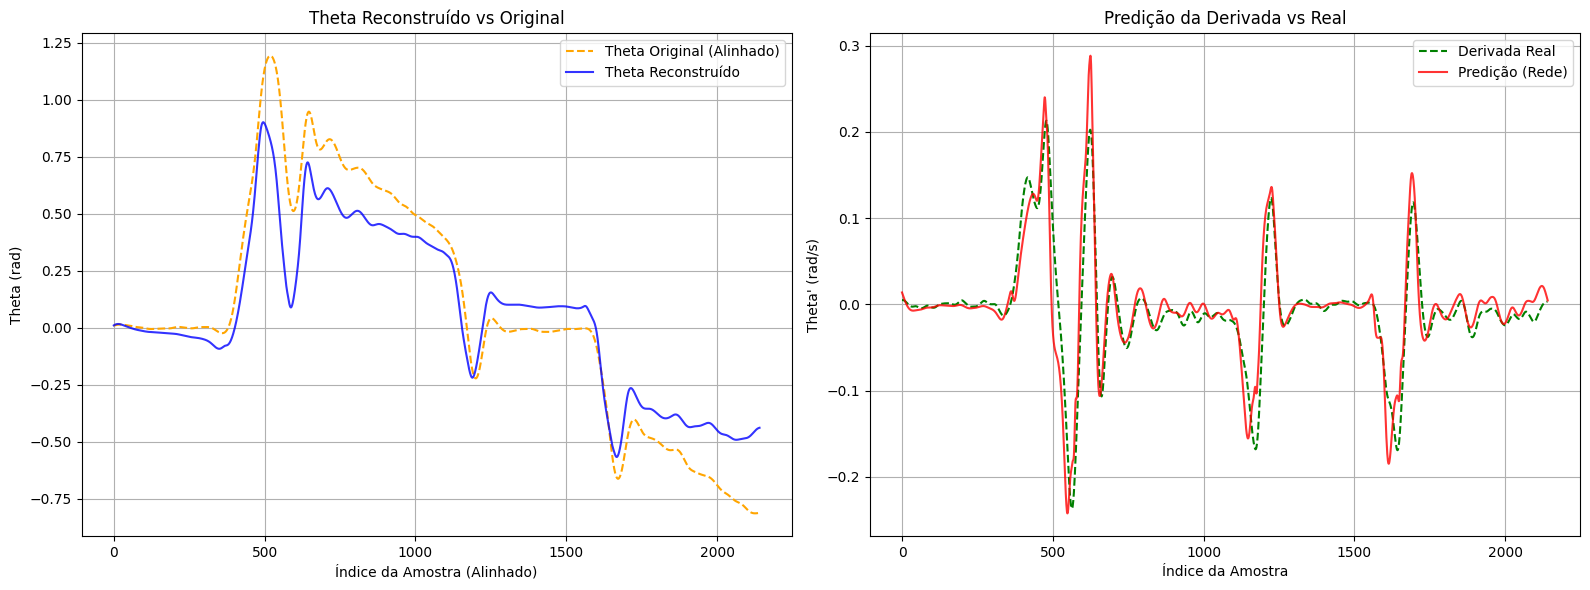

            Wd        We  delta_theta   Wd_true   We_true
0.00  1.866241  1.950911     0.007093  0.118729 -0.110797
0.07  1.870389  1.957288     0.007070  0.187222 -0.030969
0.14  1.874468  1.963593     0.007006  0.255708  0.048863
0.21  1.878425  1.969766     0.006880  0.324177  0.128705
0.28  1.882225  1.975761     0.006673  0.392606  0.208559
Shape do novo_df: (1325, 5)
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE entre Theta Original e Reconstruído: 0.06456


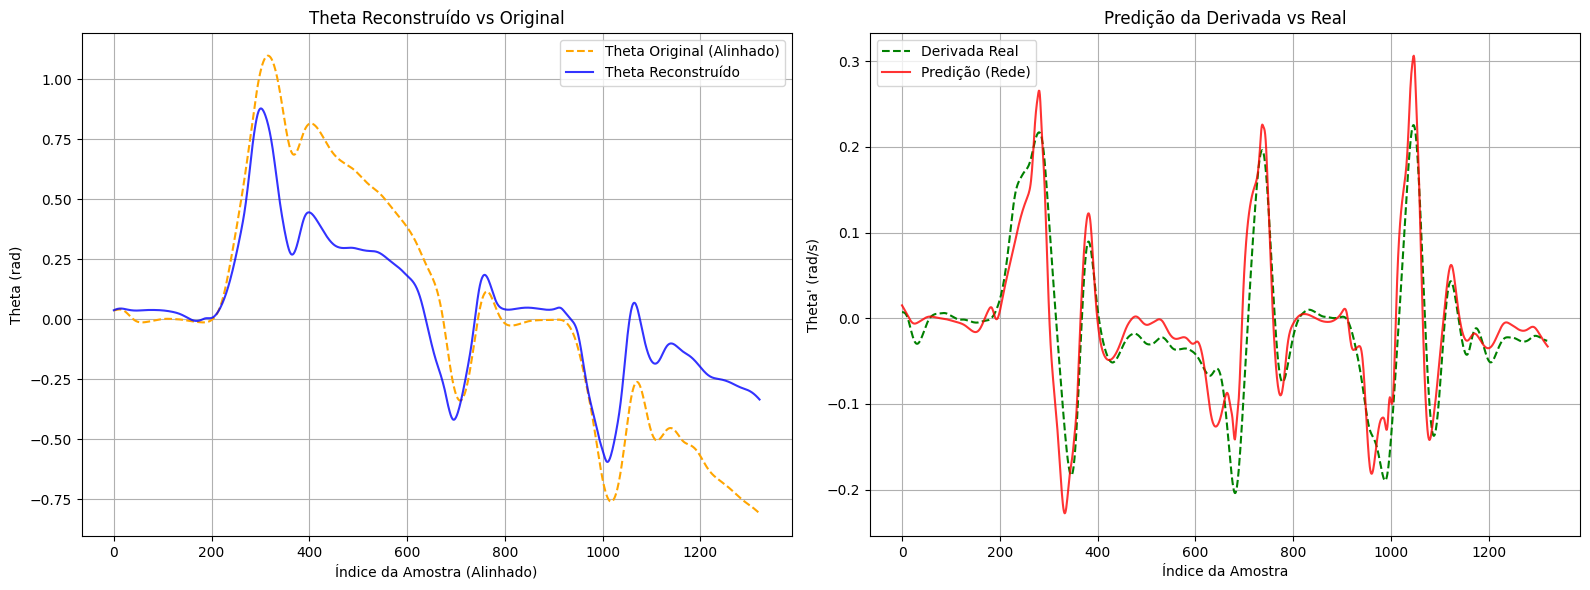

            Wd        We  delta_theta   Wd_true   We_true
0.00  2.250967  2.289211     0.008868  0.204149  0.077678
0.07  2.246293  2.286558     0.008856  0.283600  0.162385
0.14  2.241624  2.283906     0.008824  0.363042  0.247087
0.21  2.236964  2.281260     0.008762  0.442455  0.331776
0.28  2.232324  2.278624     0.008659  0.521806  0.416432
Shape do novo_df: (2026, 5)
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE entre Theta Original e Reconstruído: 0.03089


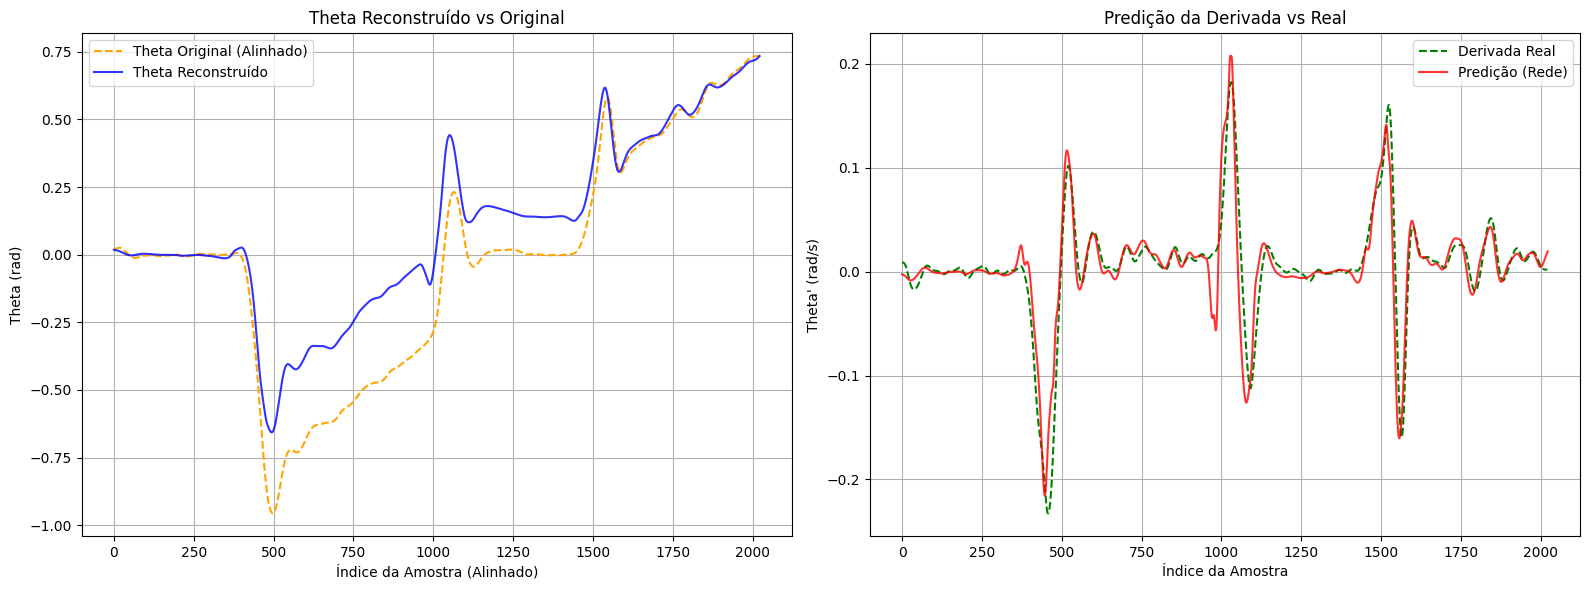

[0.03131473274038657, 0.06456490425828545, 0.03089079898894999]

In [77]:


train_x_seq, train_y_seq = create_sequences(train_x_norm, train_y_norm, 3)
x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, 3)

# Ajustar pesos da saída da penúltima RNN
#tune_model = ajustar_saida_minimos_quadrados(best_model, train_x_seq, train_y_seq)
best_model = keras.models.load_model(best_model_path)
best_model.summary()

rnn_output_model = keras.Sequential(best_model.layers[:-1])
rnn_output_model.build(input_shape=best_model.input_shape)
rnn_output_model.summary()
H = rnn_output_model.predict(x_test_seq)

print(H.shape)
print(train_y.shape)
print(train_y_seq.shape)

# Adicionar coluna de 1 para o bias
H_aug = np.hstack([H, np.ones((H.shape[0], 1))])
Y = y_test_seq 
# Resolver por mínimos quadrados
Wb, _, _, _ = np.linalg.lstsq(H_aug, Y, rcond=None)

# Separar pesos e bias
W_new = Wb[:-1, :]
b_new = Wb[-1, :]

dense_layer = best_model.layers[-1]
dense_layer.set_weights([W_new, b_new])
# Avaliar
#Aval_Thetha(tune_model, time_steps=3, y_scaler=y_scaler)
Aval_Thetha(best_model, time_steps=3, y_scaler=y_scaler)

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Shape W (8, 1) (1,)
Shape Y_old (2142, 1)
Shape delta (9, 1)
Pesos antigos [[ 0.5328414 ]
 [-0.4965122 ]
 [ 1.609174  ]
 [-0.62502086]
 [ 0.85238045]
 [ 0.23427317]
 [ 0.5984394 ]
 [ 0.32370046]] [-0.16512857]
Pesos novos [[ 0.44721959]
 [-0.46492923]
 [ 1.57525839]
 [-0.7640863 ]
 [ 0.87917173]
 [ 0.19377867]
 [ 0.58357439]
 [ 0.47182313]] [-0.12232192]
            Wd        We  delta_theta   Wd_true   We_true
0.00  2.046979  2.067159     0.004965  0.163271  0.093873
0.07  2.058519  2.079836     0.004959  0.242458  0.175944
0.14  2.069982  2.092437     0.004942  0.321637  0.258010
0.21  2.081302  2.104891     0.004909  0.400792  0.340061
0.28  2.092419  2.117138     0.004853  0.479896  0.422075
Shape do novo_df: (2145, 5)
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MSE entre Theta Original e Reconstruído: 0.02255


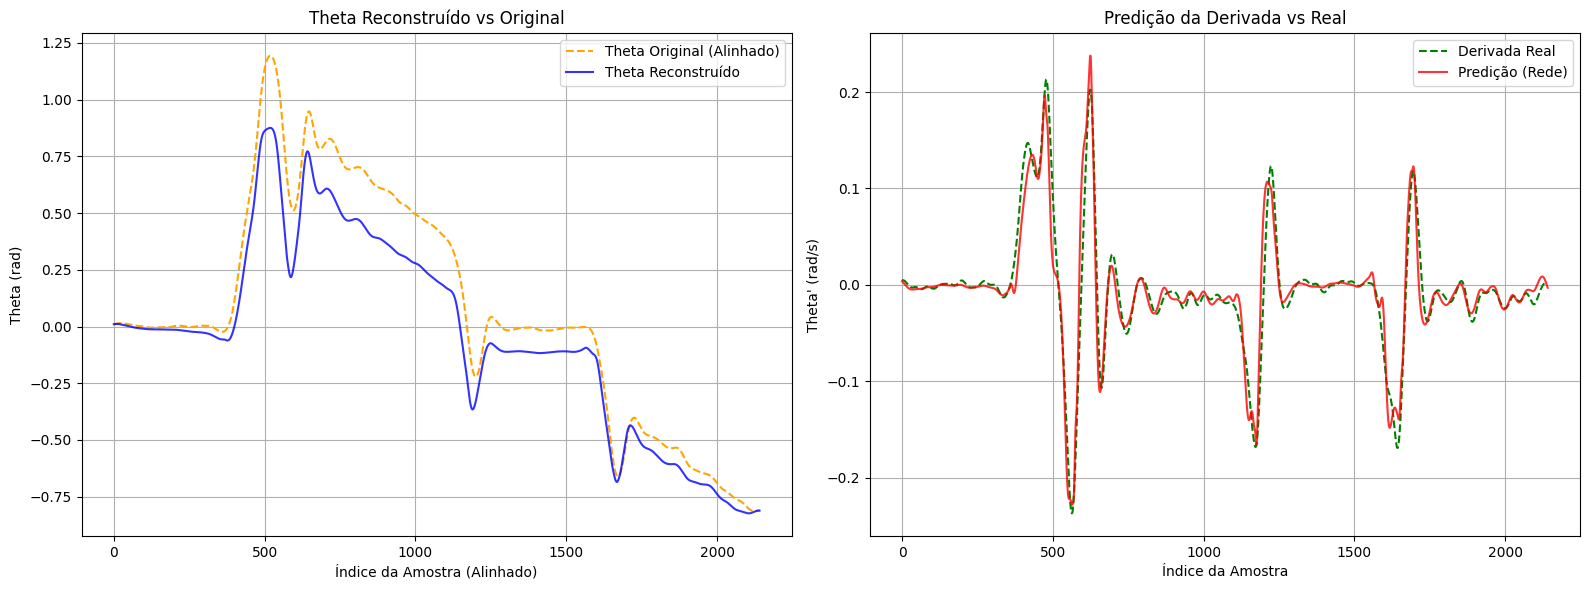

            Wd        We  delta_theta   Wd_true   We_true
0.00  1.866241  1.950911     0.007093  0.118729 -0.110797
0.07  1.870389  1.957288     0.007070  0.187222 -0.030969
0.14  1.874468  1.963593     0.007006  0.255708  0.048863
0.21  1.878425  1.969766     0.006880  0.324177  0.128705
0.28  1.882225  1.975761     0.006673  0.392606  0.208559
Shape do novo_df: (1325, 5)
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MSE entre Theta Original e Reconstruído: 0.05372


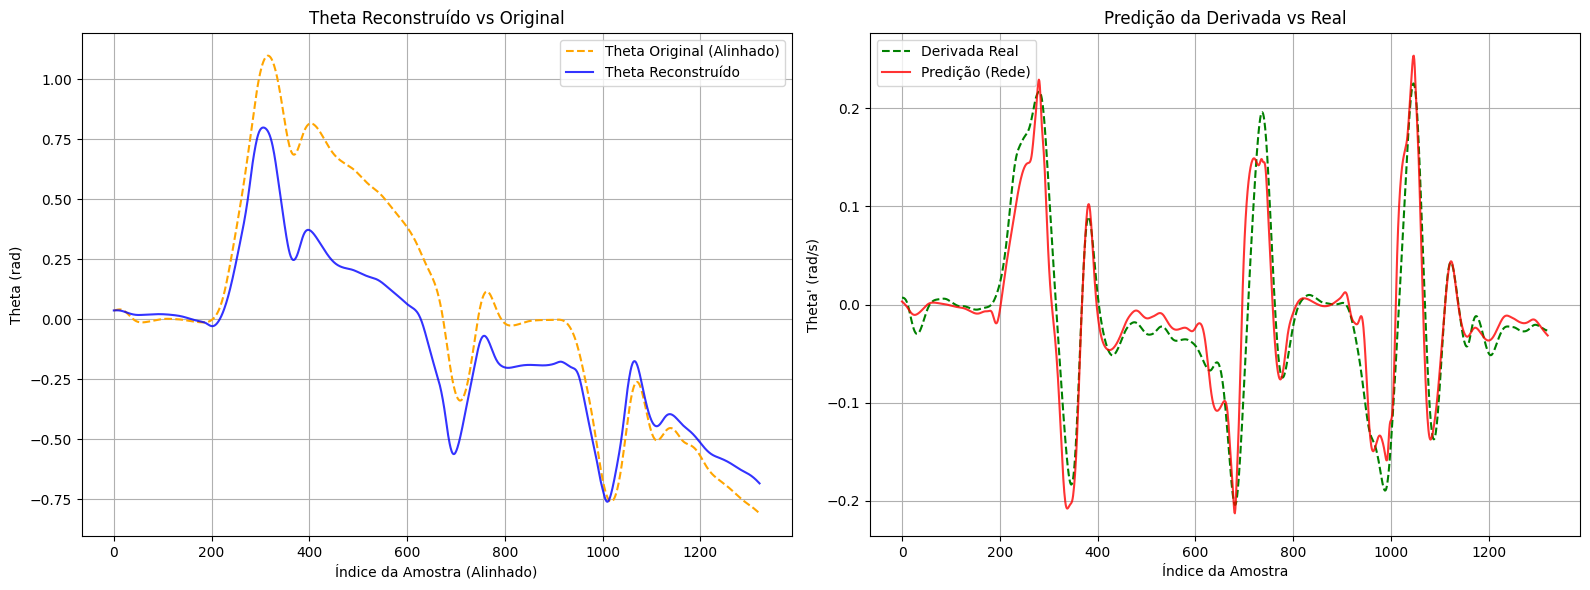

            Wd        We  delta_theta   Wd_true   We_true
0.00  2.250967  2.289211     0.008868  0.204149  0.077678
0.07  2.246293  2.286558     0.008856  0.283600  0.162385
0.14  2.241624  2.283906     0.008824  0.363042  0.247087
0.21  2.236964  2.281260     0.008762  0.442455  0.331776
0.28  2.232324  2.278624     0.008659  0.521806  0.416432
Shape do novo_df: (2026, 5)
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE entre Theta Original e Reconstruído: 0.1327


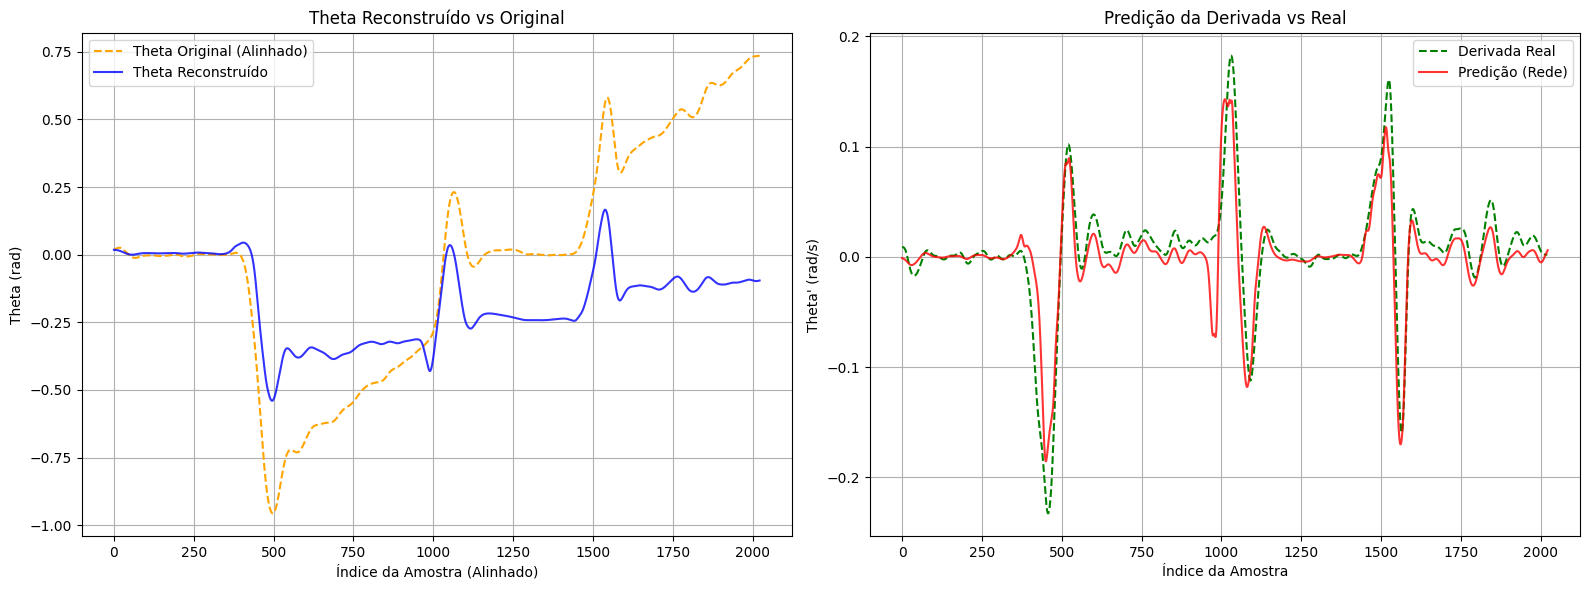

[0.022549925477045187, 0.05371789381259251, 0.1326794280046154]

In [76]:
def extrair_modelo_sem_saida(model):
    """
    Retorna um modelo novo que vai até a penúltima camada (sem a Dense final).
    Funciona tanto para modelos Sequential quanto Functional.
    """
    if isinstance(model, keras.Sequential):
        # Modelo sequencial: reconstrói até a penúltima camada
        rnn_output_model = keras.Sequential(model.layers[:-1])
        rnn_output_model.build(input_shape=model.input_shape)
    else:
        # Modelo funcional: reconstrói manualmente
        inp = Input(shape=model.input_shape[1:])
        x = inp
        for layer in model.layers[:-1]:
            x = layer(x)
        rnn_output_model = Model(inputs=inp, outputs=x)
    return rnn_output_model


def ajustar_saida_minimos_quadrados(model, X, Y):
    """
    Ajusta a camada de saída Dense de um modelo RNN por mínimos quadrados,
    partindo dos pesos originais e aplicando uma correção incremental.
    
    Retorna um NOVO modelo ajustado, sem modificar o modelo original.
    """
    # 1. Extrair submodelo até a penúltima camada
    rnn_output_model = extrair_modelo_sem_saida(model)
    
    # 2. Gerar as saídas ocultas (features)
    H = rnn_output_model.predict(X)
    
    # 3. Obter pesos originais da camada Dense
    W_old, b_old = model.layers[-1].get_weights()

    print("Shape W", W_old.shape, b_old.shape)
    
    # 4. Predição antiga
    Y_pred_old = H @ W_old + b_old

    print("Shape Y_old", Y_pred_old.shape)
    
    # 5. Resíduos
    R = Y - Y_pred_old
    
    # 6. Ajuste dos resíduos por mínimos quadrados
    H_aug = np.hstack([H, np.ones((H.shape[0], 1))])
    Delta, _, _, _ = np.linalg.lstsq(H_aug, R, rcond=None)
    print("Shape delta", Delta.shape)
    
    dW = Delta[:-1, :]
    db = Delta[-1, :]
    
    # 7. Novos pesos
    W_new = W_old + dW
    b_new = b_old + db
    
    # 8. Clonar o modelo original para não sobrescrever
    new_model = keras.models.clone_model(model)
    new_model.build(model.input_shape)
    new_model.set_weights(model.get_weights())

    print("Pesos antigos", W_old, b_old)
    print("Pesos novos", W_new, b_new)
    
    # 9. Substituir apenas a camada final
    new_model.layers[-1].set_weights([W_new, b_new])
    
    return new_model


# Carregar modelo treinado
best_model = keras.models.load_model(best_model_path)

# Ajustar saída por mínimos quadrados
tuned_model = ajustar_saida_minimos_quadrados(best_model, train_x_seq, train_y_seq)
Aval_Thetha(tuned_model, time_steps=3, y_scaler=y_scaler)

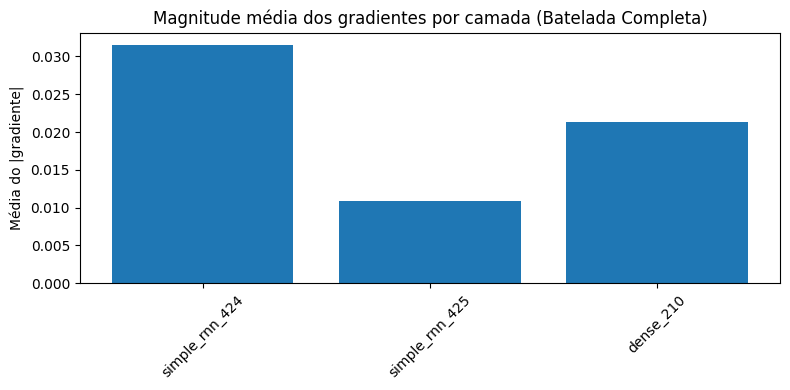

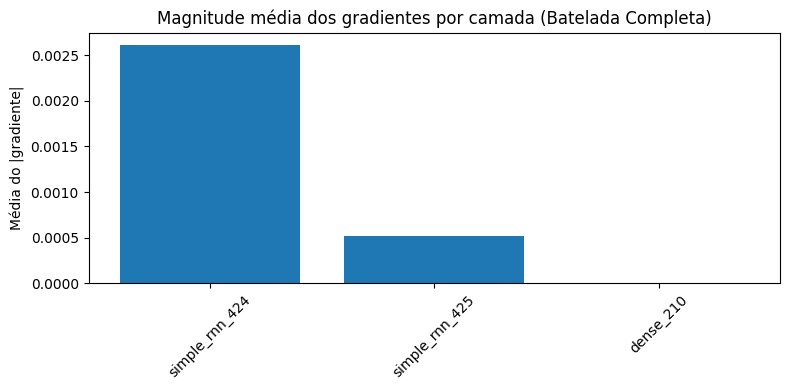

{'simple_rnn_424': 0.0026155848, 'simple_rnn_425': 0.00052070356, 'dense_210': 2.0788455e-08}


In [78]:
def avaliar_gradiente(model, x_train, y_train, loss_fn=None):
    """
    Calcula e visualiza a magnitude média dos gradientes para cada camada,
    processando todo o conjunto de dados em uma única batelada.
    """
    if loss_fn is None:
        loss_fn = tf.keras.losses.MeanSquaredError()

    # Converte os dados para tensores do TensorFlow
    x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)
    y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

    # --- INÍCIO DAS MUDANÇAS ---

    # O cálculo agora é feito fora de um loop, em todo o dataset
    with tf.GradientTape() as tape:
        # 1. Usa x_train e y_train completos, não xb e yb
        preds = model(x_train, training=True) 
        loss = loss_fn(y_train, preds)
    
    # Calcula os gradientes uma única vez para o dataset inteiro
    grads = tape.gradient(loss, model.trainable_weights)

    # 2. Calcula a média dos gradientes absolutos diretamente
    #    Não há necessidade de somar e contar, pois é uma única passagem
    grad_means_per_weight = []
    for g in grads:
        if g is not None:
            grad_means_per_weight.append(np.abs(g.numpy()).mean())
        else:
            grad_means_per_weight.append(0.0)

    # --- FIM DAS MUDANÇAS ---

    grad_means = {}
    idx = 0
    for layer in model.layers:
        if layer.trainable_weights:
            layer_grads = []
            for _ in layer.trainable_weights:
                # 3. Usa o valor já calculado, sem dividir pelo contador
                layer_grads.append(grad_means_per_weight[idx])
                idx += 1
            grad_means[layer.name] = np.mean(layer_grads)

    # A parte de visualização permanece a mesma
    plt.figure(figsize=(8,4))
    plt.bar(grad_means.keys(), grad_means.values())
    plt.xticks(rotation=45)
    plt.ylabel("Média do |gradiente|")
    plt.title("Magnitude média dos gradientes por camada (Batelada Completa)")
    plt.tight_layout()
    plt.show()
    
    return grad_means
grad_means = avaliar_gradiente(best_model, train_x_seq, train_y_seq)
grad_means = avaliar_gradiente(tuned_model, train_x_seq, train_y_seq)

print(grad_means)